# 01 · Flood labels and district points (Uttar Pradesh)

Builds the flood-onset labels and the district sampling points used by every later notebook.

**Input:** India Flood Inventory v2.0 (Saharia et al., 2021, *Natural Hazards* 108, 619–633), cloned from `msaharia/India-flood-inventory-impacts`, which also ships the district shapefile.

**Output** (`/kaggle/working/outputs`):
- `up_flood_labels.csv`: one row per district and flood onset
- `label_funnel.csv`: record counts at each filtering step, for the Data section
- `up_district_points.csv`: one point inside each district, used for rainfall and soil moisture
- `up_river_candidates.csv`: grid points per district, used in notebook 02 to pick each district's main river
- `fig_onsets_per_year.png`, `fig_onsets_by_district.png`

Requires Internet to be switched on in the notebook settings.

In [1]:
!git clone -q --depth 1 https://github.com/msaharia/India-flood-inventory-impacts.git /kaggle/working/ifi
!git -C /kaggle/working/ifi rev-parse HEAD

6affb933ba114d24db56d989c442c24794f938a9


In [2]:
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point

WORK = Path("/kaggle/working")
IFI = WORK / "ifi"
OUT = WORK / "outputs"
OUT.mkdir(exist_ok=True)

START_YEAR = 1984
END_YEAR = 2023
GRID_STEP = 0.1
BUFFER = 0.1

## Load and filter events

Dates use two-digit years, so pandas reads 1967 as 2067; those are shifted back a century. The study starts in 1984 because that is where GloFAS river discharge begins.

In [3]:
raw = pd.read_csv(IFI / "Data" / "IndiaFloodInventory.csv")
funnel = [("All events in IFI", len(raw))]

df = raw[["UEI", "Start Date", "End Date", "State", "Districts"]].copy()
df.columns = ["uei", "start", "end", "state", "districts"]
for col in ["start", "end"]:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%y %H:%M", errors="coerce")
    df.loc[df[col].dt.year > END_YEAR, col] -= pd.DateOffset(years=100)

df = df.dropna(subset=["start"])
funnel.append(("Valid start date", len(df)))

df = df[df["state"].str.contains("uttar pradesh", case=False, na=False)]
funnel.append(("State includes Uttar Pradesh", len(df)))

df = df[df["start"].dt.year.between(START_YEAR, END_YEAR)]
funnel.append((f"Start year {START_YEAR}-{END_YEAR}", len(df)))

df = df.dropna(subset=["districts"])
funnel.append(("Has district list", len(df)))
df.head()

,uei,start,end,state,districts
666,UEI-IMD-FL-1984-0086,1984-06-19,1984-06-26,Uttar Pradesh,"Basti, Deoria,Gorakhpur"
669,UEI-IMD-FL-1984-0089,1984-07-11,1984-07-11,Uttar Pradesh,Deoria
671,UEI-IMD-FL-1984-0091,1984-07-22,1984-07-28,Uttar Pradesh,"Azamgarh, Bahraich, Ballia, Bara Banki, Basti,..."
672,UEI-IMD-FL-1984-0092,1984-08-01,1984-08-21,Uttar Pradesh,"Azamgarh, Ballia, Deoria, Gorakhpur,Kheri"
673,UEI-IMD-FL-1984-0093,1984-08-31,1984-08-31,Uttar Pradesh,Varanasi


## Match district names to present-day UP

The shapefile holds the 75 current UP districts. The aliases fix misspellings and renamed districts in the inventory. Before 2000, Uttarakhand was part of UP, so events listing Uttarakhand districts under UP fall out here. So do vague entries like "parts of east UP".

In [4]:
shp = gpd.read_file(IFI / "Data" / "shapefiles" / "district_shapefile" / "India_Districts.shp")
up = shp[shp["State_Name"].str.strip().str.upper() == "UTTAR PRADESH"].copy()
up["district"] = up["Dist_Name"].str.strip().str.lower()
up = up[["district", "geometry"]].reset_index(drop=True)
len(up)

75

In [5]:
aliases = {
    "allahabad": "prayagraj",
    "raebareli": "rae bareli",
    "raibareilly": "rae bareli",
    "rai bareli": "rae bareli",
    "siddharthnagarnagar": "siddharthnagar",
    "siddharth nagar": "siddharthnagar",
    "balia": "ballia",
    "kanpur": "kanpur nagar",
    "kanpur-dehat": "kanpur dehat",
    "lakhimpur": "kheri",
    "lakhimpur kheri": "kheri",
    "bareily": "bareilly",
    "bareilli": "bareilly",
    "baharich": "bahraich",
    "shahajanpur": "shahjahanpur",
    "badaun": "budaun",
    "fatepur": "fatehpur",
    "hrawasti": "shrawasti",
    "shravasti": "shrawasti",
    "maharajganj": "mahrajganj",
    "barabanki": "bara banki",
    "ayodhya": "faizabad",
    "sant ravidas nagar": "bhadohi",
    "jyotiba phule nagar": "amroha",
    "mahamaya nagar": "hathras",
    "kanshiram nagar": "kasganj",
    "gautam budh nagar": "gautam buddha nagar",
}


def split_districts(text):
    names = re.split(r",|&| and ", text.lower())
    names = [re.sub(r"[^a-z\- ]", "", n).strip() for n in names]
    return [aliases.get(n, n) for n in names if n]


rows = df.assign(district=df["districts"].map(split_districts)).explode("district").reset_index(drop=True)
funnel.append(("District-event rows", len(rows)))

rows.loc[~rows["district"].isin(up["district"]), "district"].value_counts()

district
pithoragarh                        10
chamoli                            10
dehradun                            9
nainital                            8
garhwal                             8
tehri garhwal                       6
hardwar                             6
almora                              6
east uttar pradesh                  6
bageshwar                           4
udham singh nagar                   4
champawat                           4
uttarkashi                          3
rudraprayag                         3
parts of uttar pradesh              3
maldah                              2
many districts of uttar pradesh     2
many parts                          2
north twenty four pargan            1
murshidabad                         1
purba medinipur                     1
howrah                              1
hooghly                             1
kolkata                             1
birbhum                             1
south twenty four pargan            1
nad

In [6]:
labels = rows[rows["district"].isin(up["district"])].copy()
funnel.append(("Rows matched to a present-day UP district", len(labels)))

labels["end"] = labels[["start", "end"]].max(axis=1)
labels = labels.sort_values("uei").drop_duplicates(["district", "start"])
labels = labels[["uei", "district", "start", "end"]].sort_values(["start", "district"]).reset_index(drop=True)
labels["duration_days"] = (labels["end"] - labels["start"]).dt.days + 1
funnel.append(("Unique district-onset pairs (final labels)", len(labels)))

funnel = pd.DataFrame(funnel, columns=["step", "count"])
funnel

,step,count
0,All events in IFI,6876
1,Valid start date,6856
2,State includes Uttar Pradesh,476
3,Start year 1984-2023,423
4,Has district list,421
5,District-event rows,1770
6,Rows matched to a present-day UP district,1659
7,Unique district-onset pairs (final labels),1651


## Label checks

Recorded durations above a month are mostly season-long records (1989, 2008, 2017). Their onset date is less precise, and notebook 03 has to handle them when it masks days on which a flood is already under way.

In [7]:
print(f"Districts with at least one flood: {labels['district'].nunique()} of {len(up)}")
print(f"Onsets in June-October: {labels['start'].dt.month.between(6, 10).mean():.1%}")
long_events = labels[labels["duration_days"] > 30]
print(f"Onsets lasting over 30 days: {len(long_events)} ({len(long_events) / len(labels):.1%})")
long_events.groupby(long_events["start"].dt.year).size()

Districts with at least one flood: 75 of 75
Onsets in June-October: 79.6%
Onsets lasting over 30 days: 125 (7.6%)


start
1987     5
1989    15
1993     7
2008    75
2017    23
dtype: int64

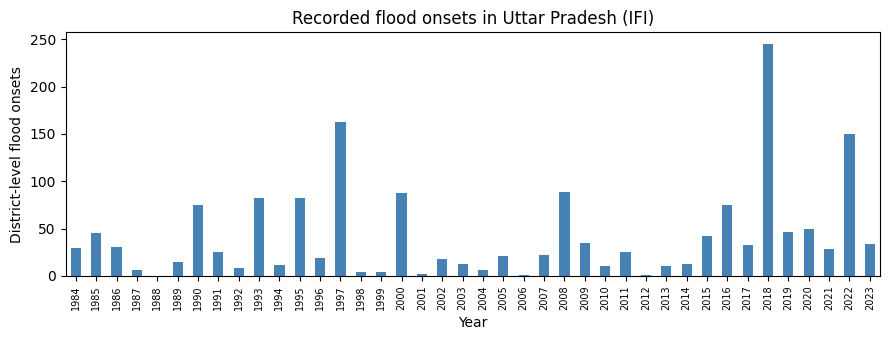

In [8]:
per_year = labels.groupby(labels["start"].dt.year).size().reindex(range(START_YEAR, END_YEAR + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 3.5))
per_year.plot.bar(ax=ax, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("District-level flood onsets")
ax.set_title("Recorded flood onsets in Uttar Pradesh (IFI)")
ax.tick_params(axis="x", labelrotation=90, labelsize=7)
fig.tight_layout()
fig.savefig(OUT / "fig_onsets_per_year.png", dpi=200)

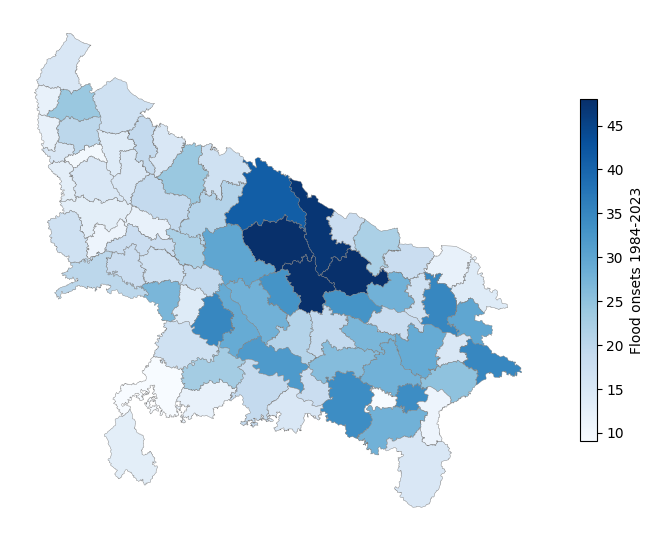

In [9]:
counts = labels.groupby("district").size().rename("onsets")
up_map = up.merge(counts, on="district", how="left").fillna({"onsets": 0})

fig, ax = plt.subplots(figsize=(7, 6))
up_map.plot(
    column="onsets",
    cmap="Blues",
    edgecolor="grey",
    linewidth=0.3,
    legend=True,
    ax=ax,
    legend_kwds={"label": f"Flood onsets {START_YEAR}-{END_YEAR}", "shrink": 0.6},
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT / "fig_onsets_by_district.png", dpi=200)

## Sampling points

Rainfall and soil moisture come from one point per district. `representative_point` is always inside the polygon; a centroid is not.

River discharge snaps to the nearest modelled river, so each district also gets a grid of candidates and notebook 02 keeps the one carrying the most water. The grid is laid over each district buffered by `BUFFER` degrees, about 11 km, because in many UP districts the main river runs along the boundary rather than through the middle: an interior-only grid leaves Faizabad, Bara Banki, Unnao and Deoria with nothing near the Ghaghara, Ganga or Yamuna, and discharge then snaps to a minor stream. Overlapping buffers are intended, so neighbouring districts can share a point on the river between them.

In [10]:
rep = up.geometry.representative_point()
points = pd.DataFrame({"district": up["district"], "lat": rep.y.round(4), "lon": rep.x.round(4)})

minx, miny, maxx, maxy = up.buffer(BUFFER).total_bounds
xs = np.arange(np.floor(minx * 10) / 10, maxx, GRID_STEP)
ys = np.arange(np.floor(miny * 10) / 10, maxy, GRID_STEP)
grid = gpd.GeoDataFrame(geometry=[Point(x, y) for x in xs for y in ys], crs=up.crs)
grid = gpd.sjoin(grid, up.assign(geometry=up.buffer(BUFFER)), predicate="within")

grid_points = pd.DataFrame(
    {"district": grid["district"], "lat": grid.geometry.y.round(4), "lon": grid.geometry.x.round(4)}
)
candidates = pd.concat([grid_points, points]).drop_duplicates()
candidates = candidates.sort_values(["district", "lat", "lon"]).reset_index(drop=True)

print(f"{len(candidates)} candidate points")
candidates.groupby("district").size().describe()

/tmp/ipykernel_16/1650560284.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  minx, miny, maxx, maxy = up.buffer(BUFFER).total_bounds
/tmp/ipykernel_16/1650560284.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid = gpd.sjoin(grid, up.assign(geometry=up.buffer(BUFFER)), predicate="within")


4614 candidate points


count     75.000000
mean      61.520000
std       18.833093
min       27.000000
25%       48.000000
50%       62.000000
75%       74.000000
max      120.000000
dtype: float64

In [11]:
labels.to_csv(OUT / "up_flood_labels.csv", index=False, date_format="%Y-%m-%d")
points.to_csv(OUT / "up_district_points.csv", index=False)
candidates.to_csv(OUT / "up_river_candidates.csv", index=False)
funnel.to_csv(OUT / "label_funnel.csv", index=False)
sorted(p.name for p in OUT.iterdir())

['fig_onsets_by_district.png',
 'fig_onsets_per_year.png',
 'label_funnel.csv',
 'up_district_points.csv',
 'up_flood_labels.csv',
 'up_river_candidates.csv']